<a href="https://colab.research.google.com/github/sultanjacob/Applied-Machine-Learning/blob/main/01_Linear_Regression/Linear_Regression_series.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Smart City Mobility: Predicting Bike Demand with Linear Regression

**Objective:** Predict the number of public rental bikes required at any given hour based on weather and time data.
**Dataset:** Seoul Bike Sharing Demand (UCI Machine Learning Repository)

In this notebook, we will move through a complete Machine Learning pipeline:
1. **Data Ingestion:** Loading the raw data.
2. **Exploratory Data Analysis (EDA):** Understanding the distributions and correlations.
3. **Data Preprocessing:** Cleaning, encoding, and scaling features for the model.
4. **Model Training:** Fitting a Multiple Linear Regression model.
5. **Evaluation:** Measuring performance using MAE, RMSE, and $R^2$.
6. **Export:** Saving the trained model for future mobile or web deployment.

In [6]:
# Import fundamental libraries for data manipulation and math
import pandas as pd
import numpy as np

# Import libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Import scikit-learn modules for modeling and evaluation
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib # For saving the model

# Set visual style for charts
sns.set_theme(style="whitegrid")

## 1. Ingesting the Raw Data
Before we can train a model, we need to see what we are dealing with. Data in the real world is rarely clean.

We are going to load the raw dataset and immediately inspect its structure.

In [7]:
# Load the dataset using a specific encoding because of special characters in the raw file
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00560/SeoulBikeData.csv"
df_raw = pd.read_csv(url, encoding='ISO-8859-1')

# 1. Let's look at the raw column names
print("--- RAW COLUMN NAMES ---")
print(df_raw.columns.tolist())
print("\n")

# 2. Let's look at the data types (Notice 'object' means string/text)
print("--- RAW DATA TYPES ---")
print(df_raw.info())

# 3. Display the first 5 rows to see the text variables
display(df_raw.head())

--- RAW COLUMN NAMES ---
['Date', 'Rented Bike Count', 'Hour', 'Temperature(°C)', 'Humidity(%)', 'Wind speed (m/s)', 'Visibility (10m)', 'Dew point temperature(°C)', 'Solar Radiation (MJ/m2)', 'Rainfall(mm)', 'Snowfall (cm)', 'Seasons', 'Holiday', 'Functioning Day']


--- RAW DATA TYPES ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Date                       8760 non-null   object 
 1   Rented Bike Count          8760 non-null   int64  
 2   Hour                       8760 non-null   int64  
 3   Temperature(°C)            8760 non-null   float64
 4   Humidity(%)                8760 non-null   int64  
 5   Wind speed (m/s)           8760 non-null   float64
 6   Visibility (10m)           8760 non-null   int64  
 7   Dew point temperature(°C)  8760 non-null   float64
 8   Solar Radiation (MJ/m2)    8760 non-

,Date,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
0,01/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,01/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,01/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,01/12/2017,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,01/12/2017,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes


From the data above, we can see the following problems:
1.  **Special Characters:** The column names contain spaces and symbols (like `°C`) which makes writing code difficult.
2.  **Wrong Data Types:** The `Date` is stored as a string (text), not a time format.
3.  **Text in a Math Problem:** Columns like `Seasons` and `Holiday` are text. A linear regression formula ($y = \beta_0 + \beta_1x_1$) cannot multiply a weight by the word "Winter".

## 2. Visualizing the Raw Data (The Problem)
What happens if we try to plot our target variable (`Rented Bike Count`) over time using the raw, uncleaned `Date` column?

Because the computer sees `Date` as an alphabetical string of text rather than a chronological timeline, the visualization becomes an unreadable, overlapping mess. This perfectly illustrates why preprocessing is mandatory.

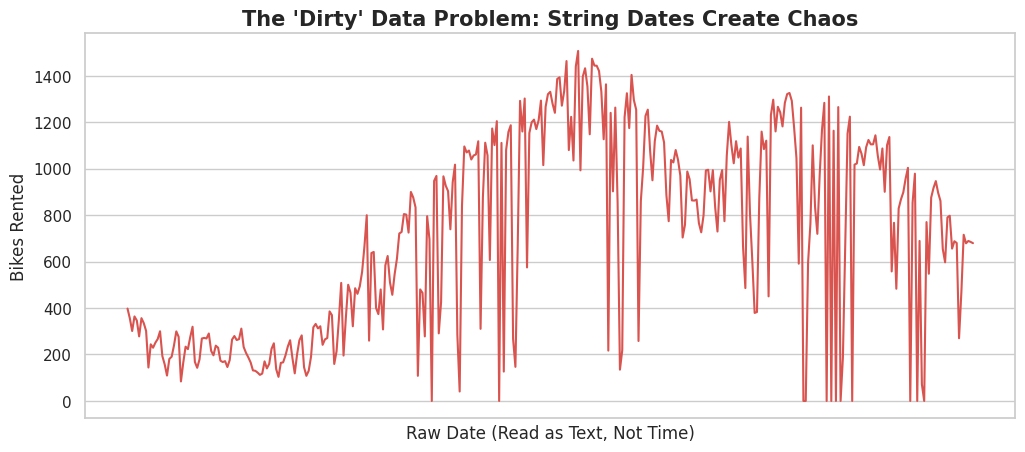

As you can see, without converting strings to proper datetime objects, temporal analysis is impossible.


In [8]:
plt.figure(figsize=(12, 5))

# Attempting to plot the raw string dates
sns.lineplot(data=df_raw, x='Date', y='Rented Bike Count', errorbar=None, color='#d9534f')

plt.title("The 'Dirty' Data Problem: String Dates Create Chaos", fontsize=15, fontweight='bold')
plt.xlabel("Raw Date (Read as Text, Not Time)", fontsize=12)
plt.ylabel("Bikes Rented", fontsize=12)

# We have to hide the X-axis labels because 365 text strings print on top of each other as a black block!
plt.xticks([])

plt.show()

print("As you can see, without converting strings to proper datetime objects, temporal analysis is impossible.")

## 3. Data Cleaning and Formatting
Now that we've identified the issues, let's fix them.
1. We will rename the columns to be code-friendly (removing spaces and symbols).
2. We will convert the `Date` column into a proper datetime object, which will allow us to extract the month and day of the week as useful numerical features.

In [9]:
# Create a copy so we preserve our raw dataframe
df_clean = df_raw.copy()

# 1. Rename columns to remove spaces and special characters
df_clean.columns = ['Date', 'Rented_Bike_Count', 'Hour', 'Temperature_C', 'Humidity_pct',
                    'Wind_Speed_ms', 'Visibility_10m', 'Dew_Point_C', 'Solar_Radiation_MJm2',
                    'Rainfall_mm', 'Snowfall_cm', 'Seasons', 'Holiday', 'Functioning_Day']

# 2. Convert Date string to proper datetime object
df_clean['Date'] = pd.to_datetime(df_clean['Date'], format='%d/%m/%Y')

# 3. Extract numerical features from the new datetime object
df_clean['Month'] = df_clean['Date'].dt.month
df_clean['DayOfWeek'] = df_clean['Date'].dt.dayofweek # 0=Monday, 6=Sunday

# Now we can drop the original Date column as the model just needs the numerical month/day
df_clean = df_clean.drop('Date', axis=1)

print("Data successfully cleaned! Here are the new data types:")
print(df_clean.dtypes)

Data successfully cleaned! Here are the new data types:
Rented_Bike_Count         int64
Hour                      int64
Temperature_C           float64
Humidity_pct              int64
Wind_Speed_ms           float64
Visibility_10m            int64
Dew_Point_C             float64
Solar_Radiation_MJm2    float64
Rainfall_mm             float64
Snowfall_cm             float64
Seasons                  object
Holiday                  object
Functioning_Day          object
Month                     int32
DayOfWeek                 int32
dtype: object


## 3. Exploratory Data Analysis (EDA)
Before training, we must understand how our features relate to our target variable (`Rented_Bike_Count`). We will build a correlation heatmap. A high positive correlation (close to 1) means as the feature increases, bike demand increases. A negative correlation (close to -1) means as the feature increases, demand drops.

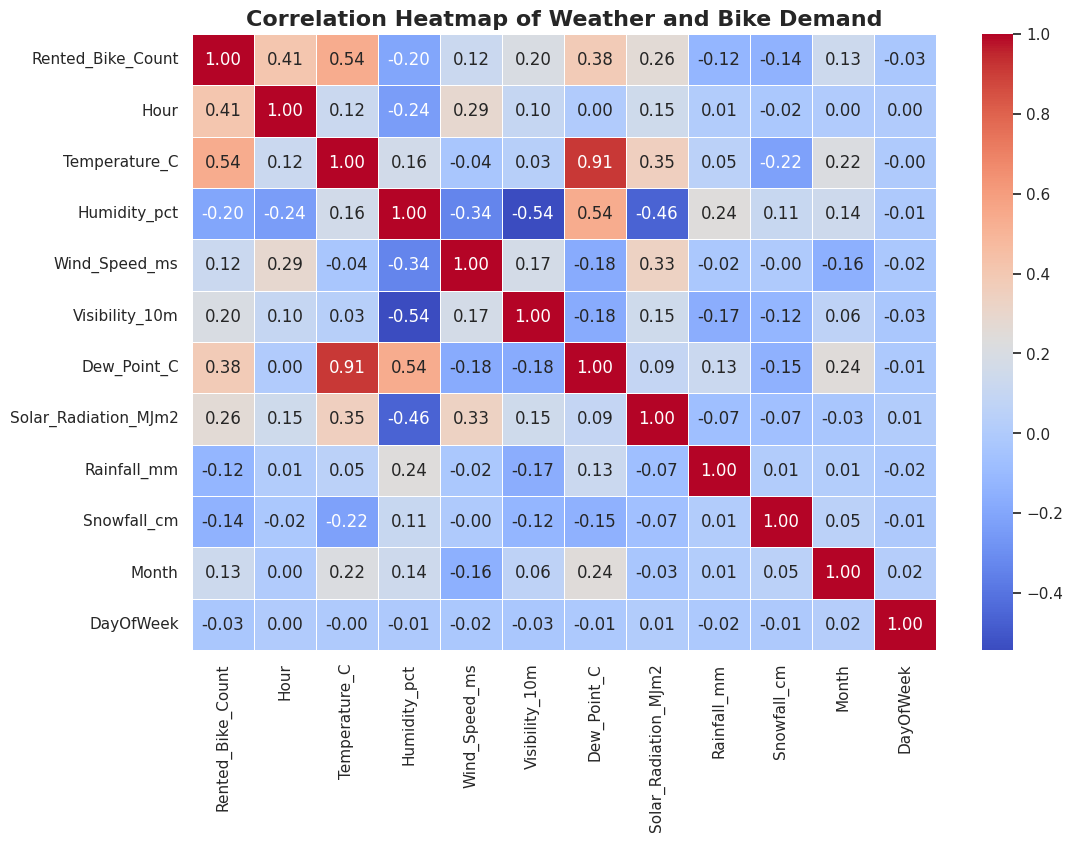

In [10]:
plt.figure(figsize=(12, 8))

# Select only numeric columns for correlation matrix
numeric_df = df_clean.select_dtypes(include=[np.number])

# Generate the heatmap
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of Weather and Bike Demand", fontsize=16, fontweight='bold')
plt.show()

## 4. Interpreting the Correlation Heatmap
The heatmap gives us a mathematical preview of our Linear Regression model. We are primarily looking at the top row: how each feature correlates with our target, `Rented_Bike_Count`.

**Key Takeaways:**
*   **Positive Drivers (Warm Colors):** `Temperature_C` (0.54) and `Hour` (0.41) have the strongest positive correlations. As temperature rises and the day progresses, bike rentals increase.
*   **Negative Drivers (Cool Colors):** `Humidity_pct` (-0.20), `Rainfall_mm` (-0.12), and `Snowfall_cm` (-0.14) have negative correlations. Bad weather means fewer rentals.
*   **Multicollinearity Warning:** Notice the 0.91 correlation between `Temperature_C` and `Dew_Point_C`. These two features represent almost the exact same information. In a highly optimized model, we might drop one to prevent them from confusing the algorithm, but we will keep them both for this baseline run.

## Handling Text Data (One-Hot Encoding)
Linear regression requires numbers, but columns like `Seasons` (Winter, Spring) and `Holiday` (No Holiday, Holiday) are text. We use "One-Hot Encoding" to convert these into binary columns (0 or 1).
We use `drop_first=True` to avoid the "dummy variable trap" (e.g., if it's not Spring, Summer, or Fall, the model mathematically knows it must be Winter).

In [11]:
# One-Hot Encode categorical variables
df_encoded = pd.get_dummies(df_clean, columns=['Seasons', 'Holiday', 'Functioning_Day'], drop_first=True)

print("Shape before encoding:", df_clean.shape)
print("Shape after encoding:", df_encoded.shape)
display(df_encoded.head(3))

Shape before encoding: (8760, 15)
Shape after encoding: (8760, 17)


,Rented_Bike_Count,Hour,Temperature_C,Humidity_pct,Wind_Speed_ms,Visibility_10m,Dew_Point_C,Solar_Radiation_MJm2,Rainfall_mm,Snowfall_cm,Month,DayOfWeek,Seasons_Spring,Seasons_Summer,Seasons_Winter,Holiday_No Holiday,Functioning_Day_Yes
0,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,12,4,False,False,True,True,True
1,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,12,4,False,False,True,True,True
2,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,12,4,False,False,True,True,True


## 6. Train-Test Split and Feature Scaling
We split our dataset so the model learns on 80% of the data and is tested on 20% it has never seen.
Then, we apply a **StandardScaler**. Because `Visibility` is measured in the thousands and `Temperature` in the tens, the model might unfairly weigh visibility simply because the numbers are bigger. Scaling puts everything on a level playing field.

In [12]:
# Separate target variable (y) from features (X)
X = df_encoded.drop('Rented_Bike_Count', axis=1)
y = df_encoded['Rented_Bike_Count']

# Split the data (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and apply the scaler
scaler = StandardScaler()
# Fit and transform the training data
X_train_scaled = scaler.fit_transform(X_train)
# Only transform the test data to prevent data leakage
X_test_scaled = scaler.transform(X_test)

## 7. Model Training
Now we feed the scaled data into the Multiple Linear Regression algorithm. It will calculate the optimal line of best fit by assigning a specific weight to each feature.

In [13]:
# Initialize the model
model = LinearRegression()

# Train the model
model.fit(X_train_scaled, y_train)

print("Linear Regression model successfully trained!")

Linear Regression model successfully trained!


## 8. Model Evaluation
To see how well our algorithm performs, we will ask it to predict bike demand using the unseen test data. We measure performance using:
*   **MAE (Mean Absolute Error):** The average number of bikes our predictions were off by.
*   **RMSE (Root Mean Squared Error):** Heavily penalizes large errors.
*   **R-Squared:** The percentage of variance in bike demand explained by our features (1.0 is perfect).

In [14]:
# Make predictions on the test set
y_pred = model.predict(X_test_scaled)

# Calculate metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f} bikes")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f} bikes")
print(f"R-Squared (R2): {r2:.4f}")

Mean Absolute Error (MAE): 330.64 bikes
Root Mean Squared Error (RMSE): 439.86 bikes
R-Squared (R2): 0.5356


## 9. Visualizing Actual vs. Predicted
Finally, let's plot our predictions against the actual historical answers. If our model was 100% perfect, every blue dot would fall exactly on the red dashed line.

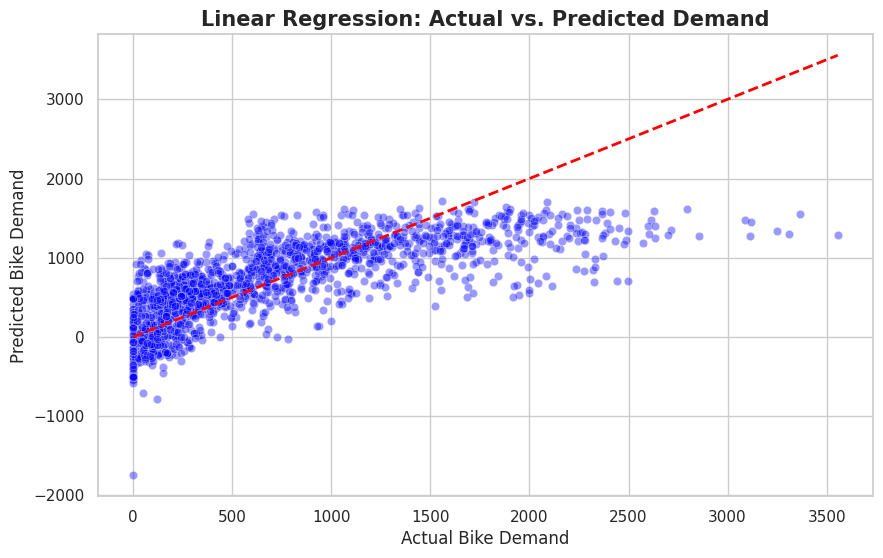

In [15]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.4, color='blue')

# Plot the line of perfect prediction
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', linewidth=2)

plt.xlabel('Actual Bike Demand', fontsize=12)
plt.ylabel('Predicted Bike Demand', fontsize=12)
plt.title('Linear Regression: Actual vs. Predicted Demand', fontsize=15, fontweight='bold')
plt.show()

## 10. The Reality Check: Analyzing Model Flaws
A data scientist's job isn't just to write code; it's to interpret the results critically. While our model learned from the data, this scatter plot reveals several critical limitations of using a basic Linear Regression algorithm for this specific real-world problem.

**How to read this chart:**
*   **The Red Line (Perfection):** This represents a 100% accurate model. If our predictions were perfectly correct, every blue dot would sit exactly on this dashed line.
*   **The Blue Dots (Our Predictions):** Each dot represents a single hour in the test dataset, showing the *actual* historical demand (X-axis) versus what our model *guessed* (Y-axis).

**Three Major Insights:**
1.  **The "Negative Bike" Problem:** Look at the bottom left of the chart. Our model predicted *negative* bike demand (e.g., -1000 bikes) for certain hours. This happens because a basic linear regression draws an infinite straight line; it doesn't intuitively know that physical inventory cannot drop below zero.
2.  **Underpredicting Peak Demand:** As actual demand gets higher (moving past 1500 on the X-axis), our blue dots fail to follow the red line upward. They plateau horizontally. This means during the busiest hours of the year, our model is severely *underpredicting* how many bikes are needed.
3.  **Non-Linearity:** The shape of the blue cloud suggests the true relationship between weather, time, and bike demand isn't a perfect straight line. There are complex, interacting factors at play.

**The Business Impact:**
If a city deployed this exact model into their mobile app backend today, they would face massive shortages during peak rush hours, and the system might crash if it tries to allocate "-500" bikes to a station.

**Next Steps:**
This is why we don't stop at Linear Regression. This baseline proves we have predictive power, but to fix the negative values and capture the peak demand, we need algorithms that can handle complex, non-linear relationships—which perfectly sets the stage for our next algorithm: **Decision Trees and Random Forests.**

## 10. Validating the L.I.N.E. Assumptions
A model might have a decent R-squared score, but if it violates the fundamental assumptions of Linear Regression, its predictions cannot be trusted in a production environment.

We will test:
1. **Linearity & Equal Variance (Homoscedasticity):** Do the errors spread evenly?
2. **Normality:** Do the errors follow a normal bell curve?
3. **Multicollinearity:** Are our features secretly overlapping and confusing the model?

In [16]:
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import scipy.stats as stats

# Calculate residuals (Actual minus Predicted)
residuals = y_test - y_pred

print("Residuals calculated successfully.")

Residuals calculated successfully.


### Assumption 1 & 2: Linearity and Homoscedasticity
We plot our predicted values against our residuals.
* **What we want to see:** A random cloud of dots scattered evenly around the zero line, like static on a TV.
* **What a failure looks like:** A clear funnel shape (meaning the model gets wildly less accurate at higher numbers) or a U-shape (meaning the relationship isn't linear).

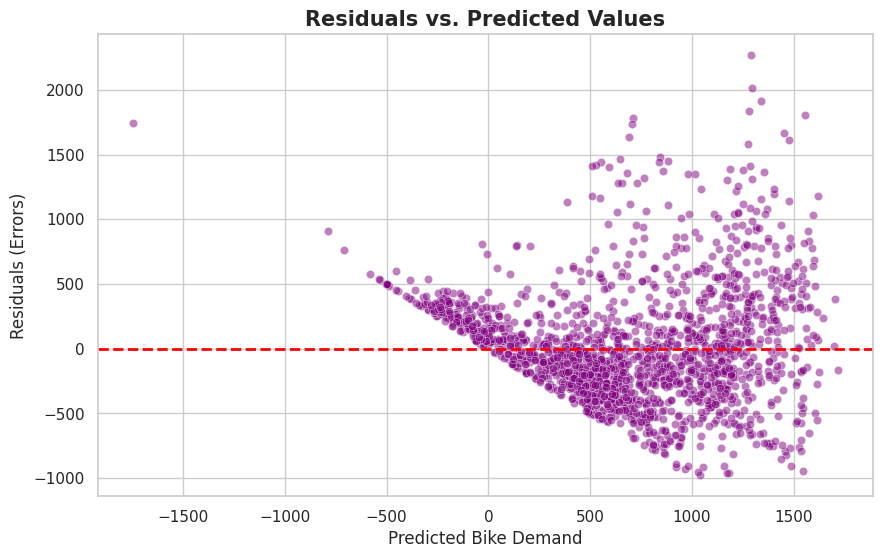

In [17]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred, y=residuals, alpha=0.5, color='purple')

# Draw a horizontal line at zero
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)

plt.xlabel('Predicted Bike Demand', fontsize=12)
plt.ylabel('Residuals (Errors)', fontsize=12)
plt.title('Residuals vs. Predicted Values', fontsize=15, fontweight='bold')
plt.show()

 ## Linearity & Homoscedasticity (Residuals vs. Predicted Values)
The scatter plot measures "Predicted Bike Demand" on the X-axis against "Residuals (Errors)" on the Y-axis, marked with a red dashed line at zero.

For a Linear Regression model to be perfectly valid, the dots should look like a random, evenly distributed cloud of static across the entire chart.

Instead, the data points form a distinct "funnel" or "fan" shape, starting tight on the left and widening significantly as the predicted bike demand increases to the right.

The Verdict (Failure): The model violates the Homoscedasticity (equal variance) assumption. When deploying this as a mobile app backend, the predictive engine would be reasonably accurate during slow hours but wildly unstable and unreliable during peak traffic times.

### Assumption 3: Normality of Residuals
Linear regression assumes that the model will make small mistakes frequently, but massive mistakes rarely.
* **What we want to see:** A beautiful, symmetrical bell curve.
* **What a failure looks like:** A heavily skewed chart, indicating the model is systematically biased in one direction.

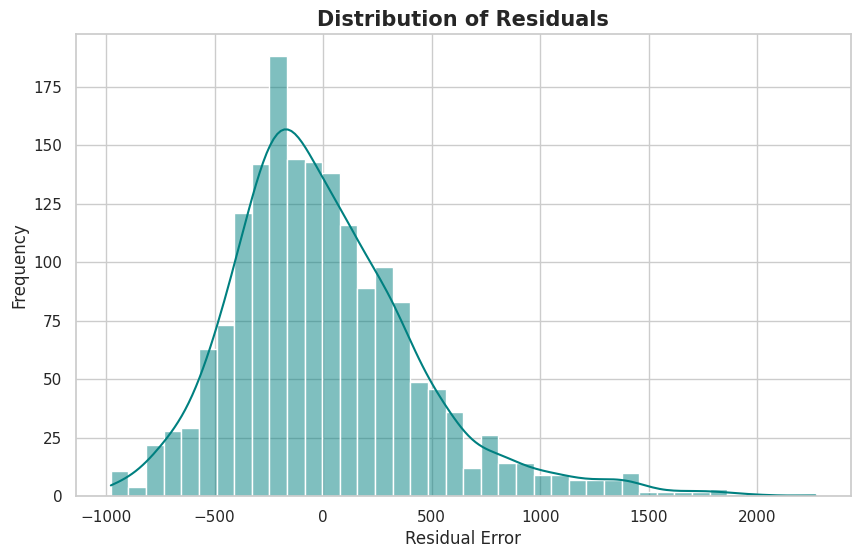

In [18]:
plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True, color='teal', bins=40)

plt.xlabel('Residual Error', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Distribution of Residuals', fontsize=15, fontweight='bold')
plt.show()

## Normality of Errors (Distribution of Residuals)
The histogram maps the frequency of the residual errors, overlaid with a distribution curve.

While the bulk of the errors cluster near the center to form a standard bell curve, the graph features a prominent, long tail stretching far to the right, passing the 1500 and 2000 marks on the X-axis.

The Verdict (Partial Failure): The residuals are not perfectly normal due to this severe right skew. This indicates that while the model usually makes standard, small mistakes, it occasionally severely underestimates the actual demand, throwing off massive errors in one specific direction.

### Assumption 4: Multicollinearity
If two features represent the exact same thing (like Temperature and Dew Point), the model's math breaks down because it can't figure out which feature deserves the weight. We measure this using the **Variance Inflation Factor (VIF)**.
* **VIF < 5:** Good. The feature is independent.
* **VIF > 10:** Danger. The feature is highly correlated with another feature and should likely be removed or penalized.

In [20]:
# Create a dataframe to store VIF results
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns

# Convert the entire dataframe to float so statsmodels can read the dummy columns
X_numeric = X.astype(float)

# Calculate VIF for each feature using the numeric dataframe
vif_data["VIF"] = [variance_inflation_factor(X_numeric.values, i)
                          for i in range(len(X_numeric.columns))]

# Sort the results to see the worst offenders at the top
vif_data = vif_data.sort_values(by="VIF", ascending=False).reset_index(drop=True)

display(vif_data.head(10))

,Feature,VIF
0,Temperature_C,57.598590
1,Dew_Point_C,37.638488
2,Humidity_pct,35.057750
3,Functioning_Day_Yes,30.501322
4,Holiday_No Holiday,19.938588
5,Visibility_10m,9.856069
6,Month,8.175095
7,Seasons_Winter,4.977503
8,Wind_Speed_ms,4.924626
9,Hour,4.535625


## Multicollinearity (The VIF Table)
The Variance Inflation Factor (VIF) table identifies features that are overlapping and feeding the algorithm redundant information.

As a standard rule, a VIF score above 5 or 10 indicates dangerous multicollinearity.

The table reveals extreme mathematical redundancy, with Temperature_C scoring 57.598590, Dew_Point_C scoring 37.638488, and Humidity_pct scoring 35.057750.

Additionally, time-based categorical features are heavily inflated, including Functioning_Day_Yes (30.501322) and Holiday_No Holiday (19.938588).

The Verdict (Failure): The model is completely failing the independence assumption. Because features like temperature and dew point are virtually identical in the eyes of the algorithm, the underlying math becomes confused and unstable, making it impossible for the model to assign the correct weights.